In [10]:
from primordialpy.background import Background
from primordialpy.model import PotentialFunction
from primordialpy.perturbations import  Perturbations
import matplotlib.pyplot as plt

## Potential

In [11]:
#KKLT inflation 
V = 'V_0*(phi**2/(phi**2 + m**2))'
parameters = {'V_0' : 0.7e-10, 'm' : 0.5}
potential = PotentialFunction.function(V, param_values=parameters) 

## Background dynamics

In [12]:

background = Background(potential, phi0 = 3.3) 
sol = background.solver()

In [13]:
N, phi, dphidN, H, a, aH, eps_H, eta_H = background.data().values()
background.save_background(path='./Data')
Nend = N[-1]
Nend

Saved to ./Data/background.dat


np.float64(63.31633163316332)

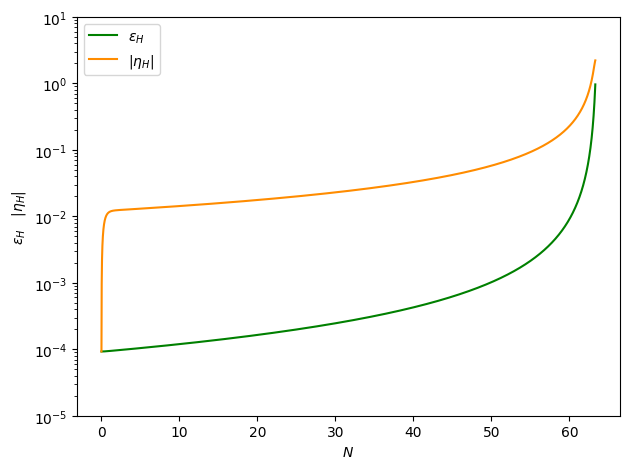

In [14]:
plt.plot(N, eps_H, label = r'$\epsilon_H$', color = 'green' )
plt.plot(N, abs(eta_H), label = r'$|\eta_H |$', color = 'darkorange')

plt.yscale('log')
plt.ylim(1e-5, 10)
plt.xlabel(r'$N$')
plt.ylabel(r'$\epsilon_H\quad |\eta_H|$')
plt.legend(loc = 'best')
#plt.title('Slow-roll parameters')
plt.tight_layout()

## Perturbations and power spectra

In [15]:
pert = Perturbations(potential, background, scale= 'CMB', N_CMB = 50.)
sol = pert.power_spectra_pivot()

Curvature power spectrum at pivot scale is 2.2374993847157744e-09
Tensor to scalar ratio at pivot scale is 0.00205979539040312


In [16]:
PS = pert.power_spectrum()
pert.save_power_spectra(path='./Data')

Computing P(k): 100%|██████████| 1000/1000 [00:11<00:00, 86.43it/s]


Saved to ./Data/power_spectra.dat


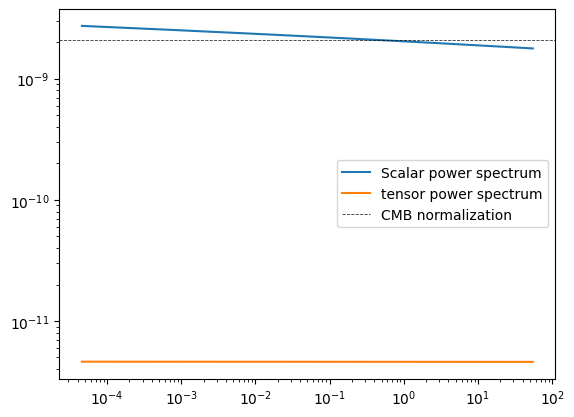

In [ ]:
plt.loglog(pert.k_modes, PS[0], label = 'Scalar power spectrum')
plt.loglog(pert.k_modes, PS[1], label = 'Tensor power spectrum')
plt.axhline(y = 2.1e-9, color = 'k', label ='CMB normalization', alpha = 0.8, linewidth = 0.6, linestyle = 'dashed')
plt.legend()

In [18]:
print(pert.spectral_tilts)

{'n_s': 0.9695500079084589, 'n_t': -0.00026554665877964197}
